# Comparaison de strategies multi-agents

Ce notebook permet de lancer plusieurs configurations de l'EDA multi-agent et de comparer :
- la fitness moyenne (`average_test_score`)
- la distance de Hamming moyenne entre agents
- la divergence de KL moyenne entre agents

L'objectif est de disposer d'un outil rapide pour tester differentes strategies (par exemple le choix de l'avantage) sans afficher le tableau de bord Tkinter. Une ligne de reference est ajoutee pour `average_test_score = -202.98`.


In [13]:
from pathlib import Path
import sys
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

try:
    import pandas as pd
except ImportError:  # pragma: no cover - depend du setup local
    pd = None
    print("Pandas n'est pas installe : les tableaux seront affiches comme dictionnaires.")

try:
    from IPython.display import display
except ImportError:  # pragma: no cover
    display = print

plt.style.use('seaborn-v0_8')

def find_repo_root(start: Optional[Path] = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / 'source_code').exists():
            return candidate
    raise RuntimeError('Impossible de localiser la racine du depot.')

REPO_ROOT = find_repo_root()
SOURCE_DIR = REPO_ROOT / 'source_code'
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))
AGENT_CFG_PATH = REPO_ROOT / 'config' / 'agent' / 'reinforce.yaml'

print(f'Repertoire racine: {REPO_ROOT}')
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch utilisera: {DEVICE}')


Repertoire racine: /home/landos/Documents/Supplementary-material
PyTorch utilisera: cpu


In [14]:
import os
from typing import Tuple

from eda_strategies.FactoryStrategyEA import FactoryStrategyEA
from environment.qubo import getTensorInstances_QUBO, get_Score_trajectoriesQUBO_cuda

factory = FactoryStrategyEA()

DEFAULT_PROBLEM_CFG: Dict[str, Any] = dict(
    type_problem='QUBO',
    dim=64,
    type_instance=0,
    nb_instances_test=10,
    nb_restarts=10,
    budget=10000,
    verbose=False,
)

def load_base_agent_cfg(config_path: Path) -> Dict[str, Any]:
    defaults: Dict[str, Any] = dict(
        lambda_=20,
        M=4,
        learning_rate=0.0,
        learning_rate_svgd=0.8,
        svgd_alpha=10.0,
        advantage='baseline',
    )
    cfg = defaults.copy()
    if config_path.exists():
        with config_path.open('r', encoding='utf-8') as fh:
            raw_cfg = yaml.safe_load(fh) or {}
        raw_cfg = raw_cfg.copy()
        if 'lambda' in raw_cfg and 'lambda_' not in raw_cfg:
            raw_cfg['lambda_'] = raw_cfg.pop('lambda')
        if 'alpha' in raw_cfg and 'svgd_alpha' not in raw_cfg:
            raw_cfg['svgd_alpha'] = raw_cfg.pop('alpha')
        cfg.update(raw_cfg)
    else:
        print(f"Avertissement: {config_path} introuvable. Utilisation des valeurs par defaut.")
    cfg['lambda_'] = int(cfg['lambda_'])
    cfg['M'] = int(cfg['M'])
    cfg['learning_rate'] = float(cfg.get('learning_rate', 0.0))
    cfg['learning_rate_svgd'] = float(cfg.get('learning_rate_svgd', 0.0))
    cfg['svgd_alpha'] = float(cfg.get('svgd_alpha', 10.0))
    cfg['advantage'] = cfg.get('advantage', 'baseline')
    return cfg

BASE_AGENT_CFG: Dict[str, Any] = load_base_agent_cfg(AGENT_CFG_PATH)

_instances_cache: Dict[Tuple[int, int, int, int, str], torch.Tensor] = {}

def load_qubo_instances(problem_cfg: Dict[str, Any]) -> torch.Tensor:
    key = (
        int(problem_cfg['dim']),
        int(problem_cfg['type_instance']),
        int(problem_cfg['nb_instances_test']),
        int(problem_cfg['nb_restarts']),
        DEVICE,
    )
    if key not in _instances_cache:
        base_path = SOURCE_DIR / 'instances' / 'QUBO'
        tensor = getTensorInstances_QUBO(
            os.fspath(base_path) + os.sep,
            key[2],
            key[3],
            key[0],
            key[1],
            DEVICE,
            'test',
        )
        _instances_cache[key] = tensor
    return _instances_cache[key]


In [15]:
def _prepare_strategy_cfg(custom_cfg: Dict[str, Any]) -> Dict[str, Any]:
    cfg = BASE_AGENT_CFG.copy()
    cfg.update(custom_cfg)
    if 'lambda' in cfg and 'lambda_' not in cfg:
        cfg['lambda_'] = cfg.pop('lambda')
    cfg.setdefault('label', f"M={cfg['M']} / lambda={cfg['lambda_']}")
    return cfg

def run_strategy(strategy_cfg: Dict[str, Any], problem_cfg: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    problem_cfg = (problem_cfg or DEFAULT_PROBLEM_CFG).copy()
    cfg = _prepare_strategy_cfg(strategy_cfg)
    label = cfg.pop('label')
    lambda_ = int(cfg['lambda_'])
    M = int(cfg['M'])
    advantage_cfg = cfg.get('advantage', 'baseline')

    dim = int(problem_cfg['dim'])
    nb_instances = int(problem_cfg['nb_instances_test'])
    nb_restarts = int(problem_cfg['nb_restarts'])
    budget = int(problem_cfg['budget'])
    verbose = bool(problem_cfg.get('verbose', False))

    tensor_Q_test = load_qubo_instances(problem_cfg)
    strategy = factory.createStrategyEA(
        'PPO-EDA',
        dim,
        lambda_,
        DEVICE,
        None,
        M,
        learning_rate=float(cfg.get('learning_rate', 0.0)),
        learning_rate_svgd=float(cfg.get('learning_rate_svgd', 0.0)),
        enable_visualization=False,
        svgd_alpha=float(cfg.get('svgd_alpha', 10.0)),
        advantage_cfg=advantage_cfg,
    ).to(DEVICE)

    scores, history = get_Score_trajectoriesQUBO_cuda(
        strategy,
        dim,
        nb_instances,
        nb_restarts,
        budget,
        lambda_,
        tensor_Q_test,
        DEVICE,
        verbose,
        name_file=None,
        enable_visualization=False,
        return_history=True,
    )

    history = history or {}
    hamming_history = history.get('avg_hamming', [])
    kl_history = history.get('avg_kl', [])
    best_fitness_history = history.get('best_fitness', [])
    # passer les - en + 
    best_fitness_history = [-x for x in best_fitness_history]

    summary = {
        'label': label,
        'config': cfg,
        'average_test_score': float(np.mean(scores)),
        'best_average_fitness': float(best_fitness_history[-1]) if best_fitness_history else float('nan'),
        'final_hamming': float(hamming_history[-1]) if hamming_history else float('nan'),
        'mean_hamming': float(np.mean(hamming_history)) if hamming_history else float('nan'),
        'final_kl': float(kl_history[-1]) if kl_history else float('nan'),
        'mean_kl': float(np.mean(kl_history)) if kl_history else float('nan'),
        'runtime': history.get('runtime', []),
        'hamming_history': hamming_history,
        'kl_history': kl_history,
        'best_fitness_history': best_fitness_history,
    }
    return summary


In [16]:
ADVANTAGE_VARIANTS = [
    ('baseline', 'Baseline'),
    ('globalrankweighted', 'Global rank weighted'),
    ('peragentrankweighted', 'Per-agent rank weighted'),
]

strategies: List[Dict[str, Any]] = [
    {
        'label': f"{label} (M={BASE_AGENT_CFG['M']}, lambda={BASE_AGENT_CFG['lambda_']}, lr_svgd={BASE_AGENT_CFG['learning_rate_svgd']}, alpha={BASE_AGENT_CFG['svgd_alpha']})",
        'advantage': advantage_name,
    }
    for advantage_name, label in ADVANTAGE_VARIANTS
]
strategies


[{'label': 'Baseline (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'baseline'},
 {'label': 'Global rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'globalrankweighted'},
 {'label': 'Per-agent rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)',
  'advantage': 'peragentrankweighted'}]

In [17]:
results: List[Dict[str, Any]] = []
for strat in strategies:
    print(f"[RUN] {strat.get('label', strat)}")
    summary = run_strategy(strat)
    results.append(summary)
print('Comparaison terminee.')

rows = [
    {
        'label': r['label'],
        'advantage': r['config'].get('advantage'),
        'best_avg_fitness': r['best_average_fitness'],
        'avg_test_score': r['average_test_score'],
        'final_hamming': r['final_hamming'],
        'final_kl': r['final_kl'],
        'mean_hamming': r['mean_hamming'],
        'mean_kl': r['mean_kl'],
    }
    for r in results
]

if pd is not None and rows:
    display(pd.DataFrame(rows).set_index('label'))
else:
    rows


[RUN] Baseline (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)
Per-agent summary:
Agent 0: avg_best_score=-185.9800, theta_mean=0.016738
Agent 1: avg_best_score=-185.6000, theta_mean=-0.026688
Agent 2: avg_best_score=-183.3000, theta_mean=-0.047192
Agent 3: avg_best_score=-182.8600, theta_mean=-0.053856
[RUN] Global rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)
Per-agent summary:
Agent 0: avg_best_score=-188.7800, theta_mean=0.051401
Agent 1: avg_best_score=-193.5000, theta_mean=-0.015560
Agent 2: avg_best_score=-193.4000, theta_mean=-0.142040
Agent 3: avg_best_score=-191.2000, theta_mean=-0.107083
[RUN] Per-agent rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)
Per-agent summary:
Agent 0: avg_best_score=-192.5000, theta_mean=-0.087253
Agent 1: avg_best_score=-193.7200, theta_mean=0.027789
Agent 2: avg_best_score=-193.0200, theta_mean=-0.001264
Agent 3: avg_best_score=-192.5600, theta_mean=0.064598
Comparaison terminee.


,advantage,best_avg_fitness,avg_test_score,final_hamming,final_kl,mean_hamming,mean_kl
label,,,,,,,
"Baseline (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)",baseline,196.559998,-196.559998,26.148333,1.073868,28.573353,0.619775
"Global rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)",globalrankweighted,202.860001,-202.860001,21.603333,1.370292,23.891293,0.844215
"Per-agent rank weighted (M=4, lambda=40, lr_svgd=1.0, alpha=15.0)",peragentrankweighted,202.539993,-202.539993,21.455000,1.621088,23.399127,0.964548


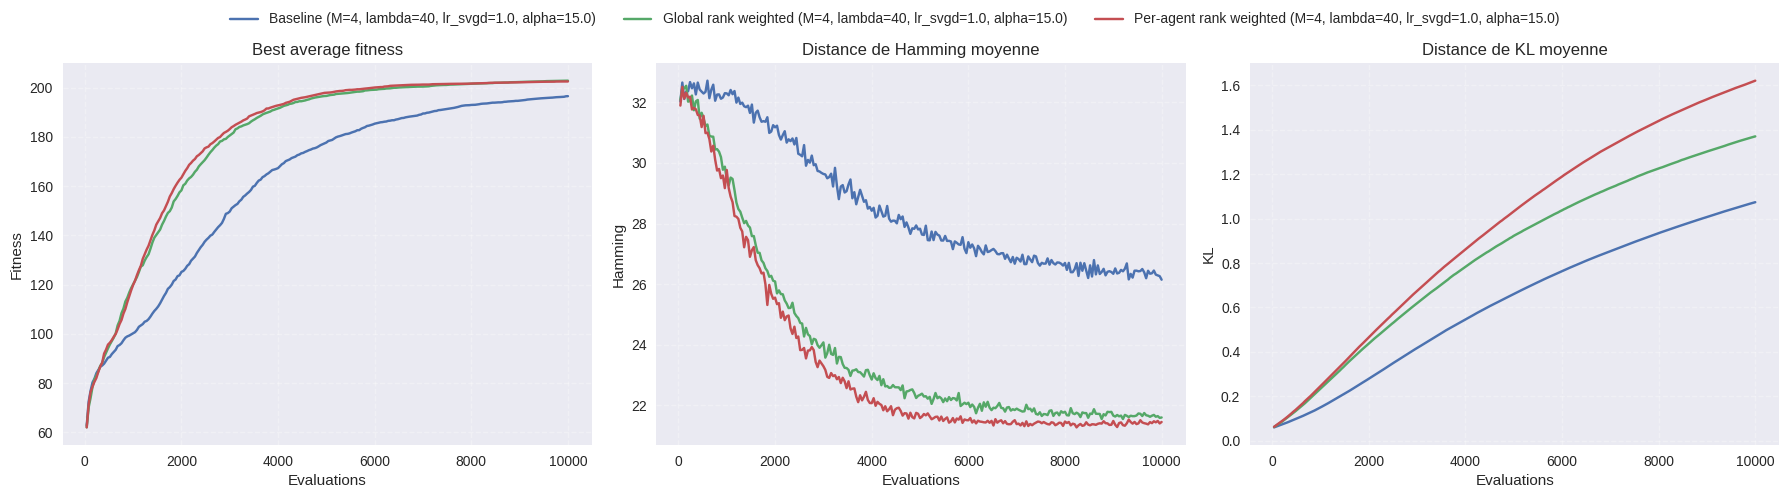

In [18]:
if results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for result in results:
        label = result['label']
        runtime = result['runtime']
        best_history = result['best_fitness_history']
        if best_history:
            steps = runtime[:len(best_history)] if runtime else list(range(1, len(best_history) + 1))
            axes[0].plot(steps, best_history, label=label)

    axes[0].set_title('Best average fitness')
    axes[0].set_xlabel('Evaluations')
    axes[0].set_ylabel('Fitness')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    for result in results:
        if result['hamming_history']:
            steps = result['runtime'][:len(result['hamming_history'])] if result['runtime'] else list(range(1, len(result['hamming_history']) + 1))
            axes[1].plot(steps, result['hamming_history'], label=result['label'])
    axes[1].set_title('Distance de Hamming moyenne')
    axes[1].set_xlabel('Evaluations')
    axes[1].set_ylabel('Hamming')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    for result in results:
        if result['kl_history']:
            steps = result['runtime'][:len(result['kl_history'])] if result['runtime'] else list(range(1, len(result['kl_history']) + 1))
            axes[2].plot(steps, result['kl_history'], label=result['label'])
    axes[2].set_title('Distance de KL moyenne')
    axes[2].set_xlabel('Evaluations')
    axes[2].set_ylabel('KL')
    axes[2].grid(True, linestyle='--', alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=min(len(handles), 3))

    fig.tight_layout(rect=(0, 0, 1, 0.95))
else:
    print('Aucun resultat a tracer pour le moment.')
